In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

seed = 42
np.random.seed(seed)

In [2]:
def update(xk, mu, sigma, delta):
    logexp = -delta * (mu - 1.5 * sigma ** 2) - delta * (sigma**2 + np.log(xk) - mu) + sigma * np.sqrt(delta) * np.random.normal(0, 1)
    return xk * np.exp(logexp)


def perform(x0, iters, mu, sigma, delta):
    for _ in range(iters):
        x0 = update(x0, mu, sigma, delta)

    return x0

In [3]:
t1 = time.time()


mu = 100
sigma = 2
delta = 0.2

x0 = 0.1
num_samples = 10000
samples = []

for index in range(num_samples):
    samples.append(perform(x0, 10000, mu, sigma, delta))
    if (index + 1) % 1000 == 0:
        print(f"{index + 1} completed.")


samples = np.array(samples)
t2 = time.time()
timetaken = t2 - t1

print(samples.shape)
print(timetaken)

1000 completed.
2000 completed.
3000 completed.
4000 completed.
5000 completed.
6000 completed.
7000 completed.
8000 completed.
9000 completed.
10000 completed.
(10000,)
452.1361312866211


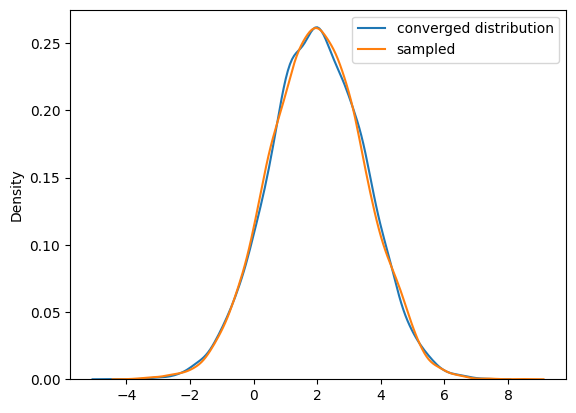

In [9]:
sns.kdeplot(np.log(samples), label="converged distribution")
sns.kdeplot(np.random.normal(0.5 * sigma ** 2, np.sqrt((1 / (2 - delta))* sigma ** 2), (10000, )), label="sampled")
plt.legend()
plt.show()